# Where should the shots go?

Four short circuits, a perfect device, and one question: **is the X gate over-rotating, and is
it tilted?**

Those are two numbers to estimate, so each circuit's usefulness is a single arrow in a plane --
which makes the whole problem something you can draw and check by hand.

Two ways to spend a fixed shot budget:

- **LM** splits it evenly. Every circuit gets the same number of shots
  (`lm_arms.py`: `per = target_shots / len(circuits)`).
- **adaptive-D** maximises `log det H` over the shot fractions and splits the budget by what
  each circuit actually measures.

All four circuits here respond to the errors we care about -- none is a throwaway. One of them
still ends up with nothing, and *why* is the point of the demo.

### No noise anywhere

The device is **ideal**: the gates are perfect. That is not a simplification for the demo's
sake, it is how experiment design actually works. You choose where to spend shots *before* you
know the errors, so the design is computed from the target gate set. A gradient here does not
say "how much error is there" -- it says "how much would this circuit's outcome move *if* there
were an error".

### The mechanism, in one box

Each circuit contributes Fisher information

    A_s = (grad p_s)(grad p_s)' / (p_s (1 - p_s))
    H(n) = sum_s n_s A_s          (n_s = shots on circuit s)

and the design maximises `det H`. A determinant is zero if **any** direction goes unmeasured,
which is what stops the budget from piling onto whichever circuit responds most strongly.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pygsti

SSE = Path.cwd()                                   # run from seed_sweep_experiments
sys.path.insert(0, str(SSE))
sys.path.insert(0, str(SSE.parent))                # GST_POUNDERS, for adaptive_shots

from gst_seed_experiment import ExperimentConfig, GSTProblem, _make_parameterized_model
import adaptive_shots as ashots

N_SHOTS = 100_000
BASELINE_FRAC = 0.001     # token uniform floor, as the production method uses

cfg = ExperimentConfig.from_json(SSE / "experiment_config.json")
prob = GSTProblem(cfg, 101)
mp = prob.modelpack
prep_fids, meas_fids = mp.prep_fiducials(), mp.meas_fiducials()

# The IDEAL gate set -- no noise. Sensitivities are evaluated at the perfect device.
ideal = _make_parameterized_model(prob.raw_target_model, cfg.parameterization,
                                  ideal_model=prob.raw_target_model)

# The two things we want to learn about the X gate.
labels = [str(l) for l in ideal.parameter_labels]
TARGET = ([i for i, l in enumerate(labels)
           if "Gxpi2" in l and l.endswith("'X Hamiltonian error coefficient')")]
          + [i for i, l in enumerate(labels)
             if "Gxpi2" in l and l.endswith("'Z Hamiltonian error coefficient')")])

print(f"{cfg.modelpack_1q}, ideal gate set, {len(labels)} model parameters in total")
print("we ask about just two of them:")
print("   dX  -- X Hamiltonian coefficient of the Gxpi2 error generator  (over-rotation)")
print("   dZ  -- Z Hamiltonian coefficient of the Gxpi2 error generator  (tilt)")

smq1Q_XYZI, ideal gate set, 72 model parameters in total
we ask about just two of them:
   dX  -- X Hamiltonian coefficient of the Gxpi2 error generator  (over-rotation)
   dZ  -- Z Hamiltonian coefficient of the Gxpi2 error generator  (tilt)


## The four circuits

Short enough to read off the page. `Gx` is `Gxpi2`, a 90-degree rotation about X; `Gy` is
`Gypi2`. Each is wrapped in preparation and measurement fiducials, which decide what the
readout can see.

| | body | readout | why it is here |
|---|---|---|---|
| **A** | `Gx` | fiducial 3 | one gate, a strong responder |
| **B** | `Gx` | fiducial 2 | **the same single gate**, read out on another axis |
| **C** | `Gy Gx Gx` | fiducial 3 | three gates, the strongest responder of the four |
| **E** | `Gy` | fiducial 1 | responds twice as strongly as B -- and gets nothing |

A and B are the pair to watch: the *same physical gate*, differing only in how the result is
read out. Any difference between them is about visibility, not about the gates.

E is the one to argue about. It is a perfectly good circuit with a real response to
over-rotation -- twice B's. Predict what it should get before running the next cells.

In [2]:
Gx = pygsti.circuits.Circuit([('Gxpi2', 0)])
Gy = pygsti.circuits.Circuit([('Gypi2', 0)])

FOUR = [("A   Gx         (readout 3)", prep_fids[0] + Gx           + meas_fids[3]),
        ("B   Gx         (readout 2)", prep_fids[0] + Gx           + meas_fids[2]),
        ("C   Gy Gx Gx   (readout 3)", prep_fids[1] + Gy + Gx + Gx + meas_fids[3]),
        ("E   Gy         (readout 1)", prep_fids[3] + Gy           + meas_fids[1])]
LABELS = [lab for lab, _ in FOUR]
CIRCS = [c for _, c in FOUR]

for lab, c in FOUR:
    print(f"{lab}")
    print(f"      full circuit (fiducials included):  {c.str}")

A   Gx         (readout 3)
      full circuit (fiducials included):  Gxpi2:0Gxpi2:0Gxpi2:0@(0)
B   Gx         (readout 2)
      full circuit (fiducials included):  Gxpi2:0Gypi2:0@(0)
C   Gy Gx Gx   (readout 3)
      full circuit (fiducials included):  Gxpi2:0Gypi2:0Gxpi2:0Gxpi2:0Gxpi2:0Gxpi2:0@(0)
E   Gy         (readout 1)
      full circuit (fiducials included):  Gxpi2:0Gxpi2:0Gypi2:0Gxpi2:0@(0)


### What each circuit can see

`grad p = (dp/ddX, dp/ddZ)` says how the outcome probability would move if the gate were
over-rotating (`dX`) or tilted (`dZ`). It is the circuit's sensitivity, and on an ideal device
it comes out exact.

In [3]:
pr = ideal.bulk_probabilities(CIRCS)
dp = ideal.sim.bulk_dprobs(CIRCS)

grad, prob_out = [], []
for c in CIRCS:
    outcome = list(ideal.probabilities(c).keys())[0]
    prob_out.append(float(pr[c].get(outcome, 0.0)))
    grad.append(np.asarray(dp[c][outcome], dtype=float)[TARGET])
grad, prob_out = np.array(grad), np.array(prob_out)


def axis_of(g):
    """Direction of a gradient in the (dX, dZ) plane, as an axis in [0, 180)."""
    return np.degrees(np.arctan2(g[1], g[0])) % 180.0


print(f"{'circuit':<30}{'p':>7}{'grad = (d/ddX, d/ddZ)':>24}{'|grad|':>9}{'axis':>8}")
for i, lab in enumerate(LABELS):
    print(f"{lab:<30}{prob_out[i]:>7.2f}"
          f"{f'({grad[i][0]:+.2f}, {grad[i][1]:+.2f})':>24}"
          f"{np.linalg.norm(grad[i]):>9.3f}{axis_of(grad[i]):>7.1f}d")
print()
print("Exact values on a perfect device: |grad| is 3, 1, sqrt(17) = 4.123 and 2, and every")
print("circuit sits at p = 0.5, so none of them is handicapped by shot noise.")
print("Every one of the four responds to the errors. None is a throwaway.")

circuit                             p   grad = (d/ddX, d/ddZ)   |grad|    axis
A   Gx         (readout 3)       0.50          (+3.00, +0.00)    3.000    0.0d
B   Gx         (readout 2)       0.50          (+0.00, -1.00)    1.000   90.0d
C   Gy Gx Gx   (readout 3)       0.50          (-4.00, -1.00)    4.123   14.0d
E   Gy         (readout 1)       0.50          (+2.00, +0.00)    2.000    0.0d

Exact values on a perfect device: |grad| is 3, 1, sqrt(17) = 4.123 and 2, and every
circuit sits at p = 0.5, so none of them is handicapped by shot noise.
Every one of the four responds to the errors. None is a throwaway.


### Who overlaps whom

Strength is not what the criterion rewards. What matters is whether a circuit's gradient points
along an **axis** no other circuit covers. Sign is irrelevant -- information depends on the
axis, not on which way the arrow points -- so a cosine of `+1` and one of `-1` both mean
"same axis".

In [4]:
print("cosine between gradients (magnitude; 1.000 = same axis, 0.000 = independent)")
print(f"{'':30}" + "".join(f"{l.split()[0]:>9}" for l in LABELS))
for i, a in enumerate(LABELS):
    row = "".join(
        f"{abs(float(grad[i] @ grad[j] / (np.linalg.norm(grad[i]) * np.linalg.norm(grad[j])))):>9.3f}"
        for j in range(len(LABELS)))
    print(f"{a:<30}{row}")
print()
print("A and E are on EXACTLY the same axis (1.000). E is the shorter of the two.")
print("A and C are 14 degrees apart (0.970) -- they largely duplicate each other.")
print("A and B are exactly perpendicular (0.000) -- B is the only circuit that sees the tilt.")

cosine between gradients (magnitude; 1.000 = same axis, 0.000 = independent)
                                      A        B        C        E
A   Gx         (readout 3)        1.000    0.000    0.970    1.000
B   Gx         (readout 2)        0.000    1.000    0.243    0.000
C   Gy Gx Gx   (readout 3)        0.970    0.243    1.000    0.970
E   Gy         (readout 1)        1.000    0.000    0.970    1.000

A and E are on EXACTLY the same axis (1.000). E is the shorter of the two.
A and C are 14 degrees apart (0.970) -- they largely duplicate each other.
A and B are exactly perpendicular (0.000) -- B is the only circuit that sees the tilt.


## The two allocations

`allocate_shots_per_circuit` is the same function the production runs call. LM's rule is the one
line from `lm_arms.py`.

In [5]:
J = grad
p_rows = prob_out
row_circuit = np.arange(len(FOUR))

base = np.full(len(FOUR), BASELINE_FRAC * N_SHOTS / len(FOUR))
extra, _ = ashots.allocate_shots_per_circuit(
    J, p_rows, int((1 - BASELINE_FRAC) * N_SHOTS), row_circuit,
    n_circuit=base, criterion="D", max_iter=4000)
d_share = 100.0 * (base + extra) / N_SHOTS
lm_share = np.full(len(FOUR), 100.0 / len(FOUR))     # per = target_shots / len(circuits)

print(f"{'circuit':<30}{'|grad|':>9}{'axis':>8}{'LM':>9}{'adaptive-D':>13}")
for i, lab in enumerate(LABELS):
    print(f"{lab:<30}{np.linalg.norm(grad[i]):>9.3f}{axis_of(grad[i]):>7.1f}d"
          f"{lm_share[i]:>8.1f}%{d_share[i]:>12.1f}%")
print()
print(f"B is the WEAKEST circuit (|grad| {np.linalg.norm(grad[1]):.0f}) and gets "
      f"{d_share[1]:.0f}%.")
print(f"E is twice as strong (|grad| {np.linalg.norm(grad[3]):.0f}) and gets "
      f"{d_share[3]:.0f}%.")

circuit                          |grad|    axis       LM   adaptive-D


A   Gx         (readout 3)        3.000    0.0d    25.0%        10.0%
B   Gx         (readout 2)        1.000   90.0d    25.0%        45.0%
C   Gy Gx Gx   (readout 3)        4.123   14.0d    25.0%        45.0%
E   Gy         (readout 1)        2.000    0.0d    25.0%         0.0%

B is the WEAKEST circuit (|grad| 1) and gets 45%.
E is twice as strong (|grad| 2) and gets 0%.


### Reading the result

**E is rejected despite being a good circuit.** Its gradient is 2.0 -- twice B's -- and it
responds to exactly the error we are trying to measure. But it lies on *precisely* the same
axis as A (cosine 1.000), and A responds more strongly along that axis. Anything E could
contribute, A already contributes better, so every shot given to E would be a shot that A
would have spent more effectively. E gets nothing.

**B is funded despite being the weakest.** Its gradient is 1.0, half of E's, but it is exactly
perpendicular to A -- the only circuit in the set that can see whether the gate is *tilted*.
Starve B and that direction goes unmeasured, which sends `det H` to zero no matter how many
shots the others receive.

**So the weakest circuit gets 45% and a circuit twice as strong gets 0%.** The difference
between them has nothing to do with how strongly they respond:

> **Shots follow uniqueness, not strength.** A circuit is funded for the directions only it can
> see, not for how strongly it responds.

**A is squeezed to 10%** for the same reason in milder form. It shares an axis with C (cosine
0.970), so between them they cover one direction and have to split its half of the budget; C
does the job better and takes most of it.

And note what this says about *equal* splits. If several circuits each owned a different axis,
they would get equal shares regardless of their strengths, because each would own one direction
outright. Equal shares are not the allocator idling -- they are what one-circuit-per-direction
looks like.

## The figure

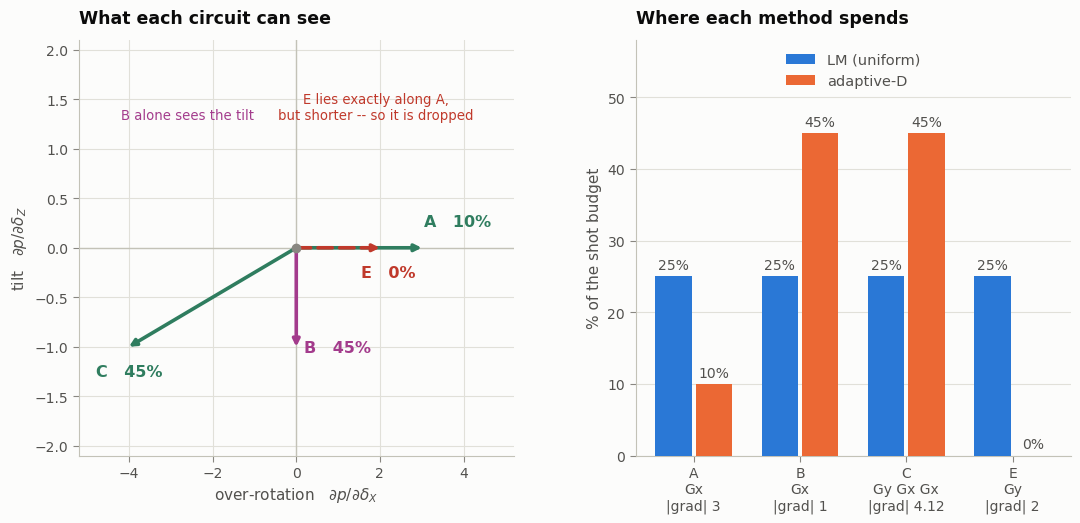

written: C:\Users\athar\Documents\Codex\ANL_SummerInternship\can-you-write-a-code-for\IBCDFO\GST_POUNDERS\seed_sweep_experiments\allocator_demo.png


In [6]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
SHARED, SOLO, DROPPED = "#2f7d5f", "#a33b8c", "#c0392b"

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.4), facecolor=SURFACE)
fig.subplots_adjust(wspace=0.28)

# ---- left: the gradients as arrows in the (dX, dZ) plane -----------------------------
ax = axes[0]
ax.set_facecolor(SURFACE)
ax.axhline(0, color=AXIS, lw=1, zorder=1)
ax.axvline(0, color=AXIS, lw=1, zorder=1)

style = {0: (SHARED, "-", 2.6), 1: (SOLO, "-", 2.6),
         2: (SHARED, "-", 2.6), 3: (DROPPED, (0, (4, 2)), 2.6)}
for i in range(4):
    g = grad[i]
    col, dash, lw = style[i]
    ax.annotate("", xy=(g[0], g[1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=col, lw=lw, linestyle=dash,
                                shrinkA=0, shrinkB=0), zorder=4 if i == 3 else 3)
lab_at = {0: (3.05, 0.22), 1: (0.18, -1.05), 2: (-4.0, -1.30), 3: (1.55, -0.30)}
for i, (lx, ly) in lab_at.items():
    ax.annotate(f"{LABELS[i].split()[0]}   {d_share[i]:.0f}%", (lx, ly),
                color=style[i][0], fontsize=11.5, fontweight="semibold",
                ha="left" if lx >= 0 else "center")
ax.plot(0, 0, "o", ms=6, color=MUTED, zorder=5)

ax.set_xlim(-5.2, 5.2)
ax.set_ylim(-2.1, 2.1)
ax.set_xlabel("over-rotation   $\partial p / \partial \delta_X$", color=INK2, fontsize=11)
ax.set_ylabel("tilt   $\partial p / \partial \delta_Z$", color=INK2, fontsize=11)
ax.set_title("What each circuit can see", color=INK, fontsize=12.5,
             fontweight="semibold", loc="left", pad=12)
ax.tick_params(colors=MUTED, labelcolor=INK2, length=4)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(AXIS)
ax.grid(True, color=GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.annotate("E lies exactly along A,\nbut shorter -- so it is dropped", (1.9, 1.30),
            color=DROPPED, fontsize=9.5, ha="center")
ax.annotate("B alone sees the tilt", (-2.6, 1.30), color=SOLO, fontsize=9.5, ha="center")

# ---- right: the two allocations -------------------------------------------------------
ax = axes[1]
ax.set_facecolor(SURFACE)
ax.grid(True, axis="y", color=GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
x = np.arange(len(FOUR))
ax.bar(x - 0.19, lm_share, width=0.34, color=BLUE, label="LM (uniform)", zorder=3)
ax.bar(x + 0.19, d_share, width=0.34, color=ORANGE, label="adaptive-D", zorder=3)
for xi, (lo, hi) in enumerate(zip(lm_share, d_share)):
    ax.annotate(f"{lo:.0f}%", (xi - 0.19, lo), textcoords="offset points", xytext=(0, 5),
                ha="center", color=INK2, fontsize=10)
    ax.annotate(f"{hi:.0f}%", (xi + 0.19, hi), textcoords="offset points", xytext=(0, 5),
                ha="center", color=INK2, fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([f"A\nGx\n|grad| {np.linalg.norm(grad[0]):.0f}",
                    f"B\nGx\n|grad| {np.linalg.norm(grad[1]):.0f}",
                    f"C\nGy Gx Gx\n|grad| {np.linalg.norm(grad[2]):.2f}",
                    f"E\nGy\n|grad| {np.linalg.norm(grad[3]):.0f}"], fontsize=10)
ax.set_ylabel("% of the shot budget", color=INK2, fontsize=11)
ax.set_ylim(0, 58)
ax.set_title("Where each method spends", color=INK, fontsize=12.5,
             fontweight="semibold", loc="left", pad=12)
ax.tick_params(colors=MUTED, labelcolor=INK2, length=4)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(AXIS)
leg = ax.legend(frameon=False, fontsize=10.5, loc="upper center")
for t in leg.get_texts():
    t.set_color(INK2)

fig.savefig(SSE / "allocator_demo.png", dpi=170, bbox_inches="tight", facecolor=SURFACE)
plt.show()
print(f"written: {SSE / 'allocator_demo.png'}")

## Summary

| circuit | body | `\|grad\|` | axis | shares an axis with | LM | adaptive-D |
|---|---|---|---|---|---|---|
| **A** | `Gx` | 3.000 | 0 deg | C (0.970), E (1.000) | 25% | 10% |
| **B** | `Gx` | 1.000 | 90 deg | nothing | 25% | **45%** |
| **C** | `Gy Gx Gx` | 4.123 | 14 deg | A (0.970) | 25% | 45% |
| **E** | `Gy` | 2.000 | 0 deg | A (1.000), and A is longer | 25% | **0%** |

A perfect device, four short circuits, two things to learn, and every circuit responds to the
errors. Nothing here depends on a noise model or on any particular error being present.

The pair to take away is **B and E**. E responds twice as strongly as B. B gets 45% of the
budget and E gets none. The only difference between them is that B is alone on its axis while E
stands behind a stronger circuit on the same one.

Strength buys nothing on its own. What a circuit is paid for is the direction only it can see.